#  Experiment 8: Loss Function Battle

## Phase 2 Optimization: MMD vs KL Divergence

**Objective:** Compare loss functions for training QCBM on discrete probability distributions.

**Contestants:**
1. **MMD (Maximum Mean Discrepancy):** Kernel-based distance
2. **KL Divergence:** Information-theoretic divergence

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import create_entangled_qcbm
from src.data.datasets import get_trap_dataset
from src.training.trainer import Trainer
from src.training.loss_functions import mmd_loss, kl_divergence, fidelity
from src.utils.visualization import set_style, plot_multiple_loss_curves
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Understanding the Loss Functions

### MMD (Maximum Mean Discrepancy)
$$\text{MMD}^2(p, q) = \mathbb{E}_{x,x' \sim p}[k(x,x')] + \mathbb{E}_{y,y' \sim q}[k(y,y')] - 2\mathbb{E}_{x \sim p, y \sim q}[k(x,y)]$$

**Advantages:**
- Symmetric
- No log(0) issues
- Smooth gradients

### KL Divergence
$$D_{KL}(p \| q) = \sum_x p(x) \log \frac{p(x)}{q(x)}$$

**Issues:**
- Asymmetric
- Undefined when supports don't overlap
- Can spike to infinity

In [2]:
# Load dataset
dataset = get_trap_dataset(n_qubits=4)
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   States: {dataset.n_states}")
print(f"   Sparsity: {100 * dataset.sparsity:.1f}%")

# Show the disjoint support problem
zero_prob_states = np.sum(target < 1e-10)
print(f"\n States with ~zero probability: {zero_prob_states}")
print("   This is problematic for KL divergence!")

 Dataset: Complex_bimodal_8q
   States: 256
   Sparsity: 0.0%

 States with ~zero probability: 0
   This is problematic for KL divergence!


## 2. The Battle: Train with Each Loss Function

In [6]:
# Configuration
loss_functions = ['mmd', 'kl']
N_QUBITS = 8
N_LAYERS = 3
N_ITERATIONS = 200

results = {}

# Use same initial params
reference_qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
initial_params = reference_qcbm.get_initial_params(seed=RANDOM_SEED)

for loss_fn in loss_functions:
    print(f"\n{'='*60}")
    print(f" Training with {loss_fn.upper()} Loss")
    print(f"{'='*60}")
    
    qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
    
    trainer = Trainer(
        qcbm=qcbm,
        target_distribution=target,
        loss_function=loss_fn,
        optimizer='Powell'  # Winner from previous experiment
    )
    
    result = trainer.train(
        n_iterations=N_ITERATIONS,
        initial_params=initial_params.copy(),
        verbose=True
    )
    
    results[loss_fn] = {
        'result': result,
        'qcbm': qcbm
    }
    
    print(f"\n Final Loss: {result.final_loss:.6f}")
    print(f" Final Fidelity: {result.final_fidelity:.4f}")


 Training with MMD Loss



 Training with MMD Loss


Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]                        
Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]



 Training with MMD Loss


Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]                        
Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]


...


 Training with MMD Loss


Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]                        
Training QCBM: 2000it [00:41, 48.21it/s, loss=0.0065, fidelity=0.8267]



 Final Loss: 0.006490
 Final Fidelity: 0.8267

 Training with KL Loss


Training QCBM: 2000it [00:35, 56.11it/s, loss=0.0720, fidelity=0.9813]                        


 Final Loss: 0.071961
 Final Fidelity: 0.9813


## 3. Training Dynamics Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp08_loss_function_comparison.png


 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp08_loss_function_comparison.png


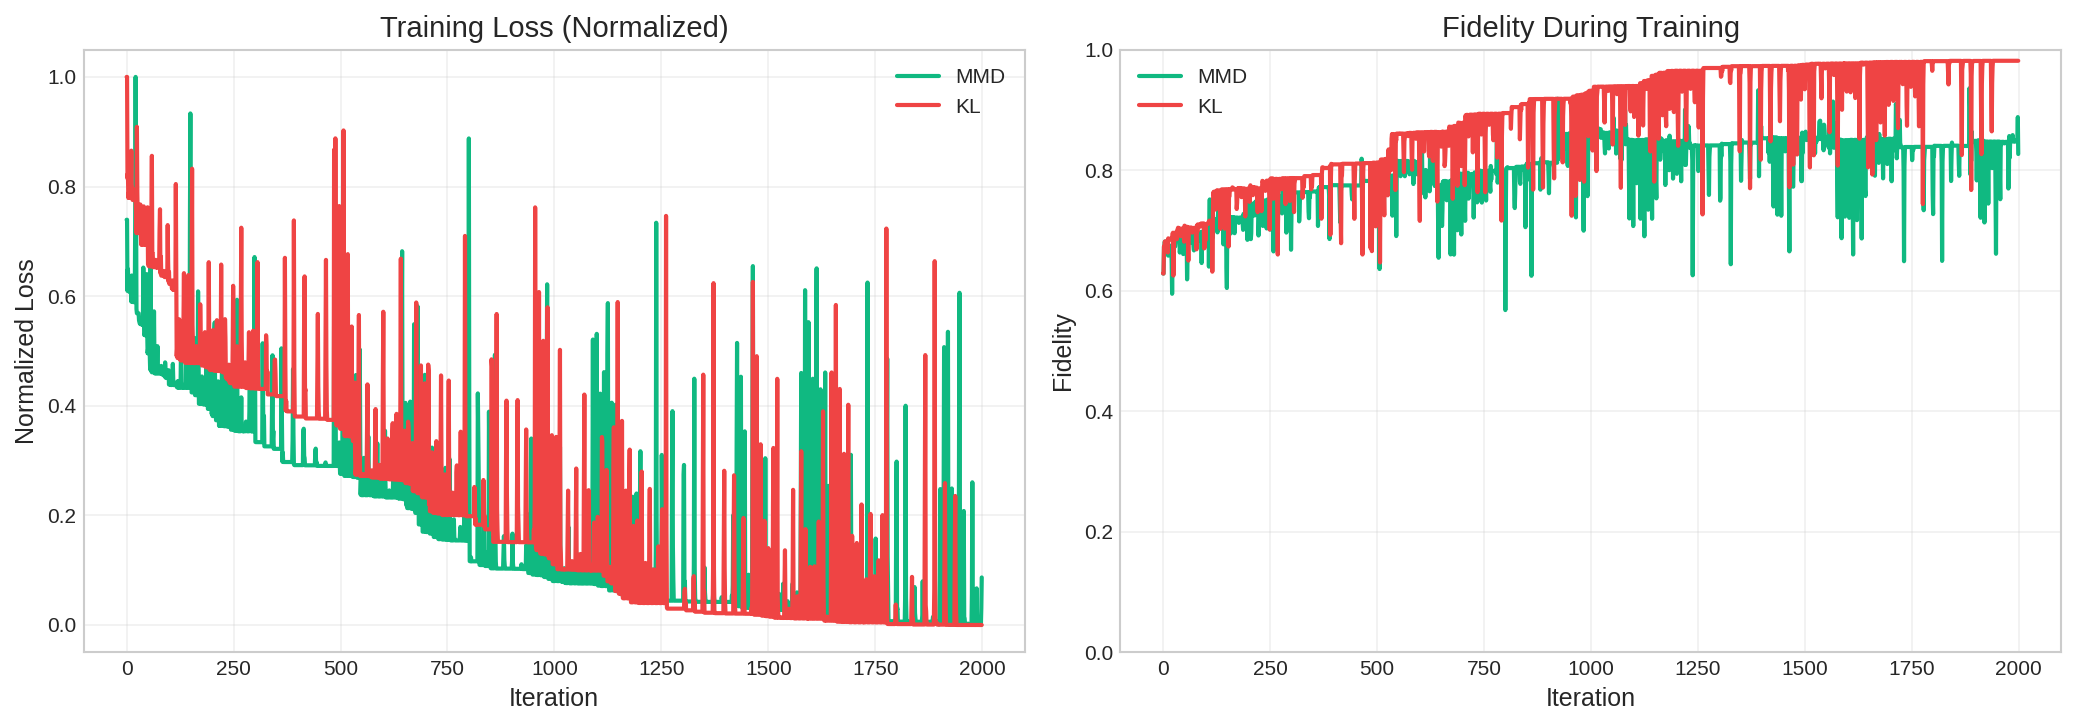

In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'mmd': '#10B981',  # Green
    'kl': '#EF4444'    # Red
}

# Loss curves (normalized for comparison)
ax = axes[0]
for loss_fn, data in results.items():
    history = data['result'].loss_history
    # Normalize to [0, 1] for comparison
    normalized = (np.array(history) - min(history)) / (max(history) - min(history) + 1e-10)
    ax.plot(normalized, label=loss_fn.upper(), color=colors[loss_fn], linewidth=2)
    
ax.set_xlabel('Iteration')
ax.set_ylabel('Normalized Loss')
ax.set_title('Training Loss (Normalized)')
ax.legend()
ax.grid(True, alpha=0.3)

# Fidelity curves
ax = axes[1]
for loss_fn, data in results.items():
    ax.plot(data['result'].fidelity_history, label=loss_fn.upper(), 
            color=colors[loss_fn], linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity During Training')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
save_figure(fig, 'loss_function_comparison', experiment='exp08')
plt.show()

## 4. Stability Analysis

In [8]:
# Check for spikes in KL divergence
print(" TRAINING STABILITY")
print("=" * 60)

for loss_fn, data in results.items():
    history = data['result'].loss_history
    
    # Detect spikes (sudden large increases)
    diffs = np.diff(history)
    n_spikes = np.sum(diffs > np.mean(np.abs(diffs)) * 5)
    max_spike = np.max(diffs)
    
    print(f"\n{loss_fn.upper()} Loss:")
    print(f"   Initial value: {history[0]:.6f}")
    print(f"   Final value: {history[-1]:.6f}")
    print(f"   Min value: {min(history):.6f}")
    print(f"   Max value: {max(history):.6f}")
    print(f"   Number of spikes: {n_spikes}")
    print(f"   Largest spike: {max_spike:.6f}")

 TRAINING STABILITY

MMD Loss:
   Initial value: 0.041574
   Final value: 0.006490
   Min value: 0.001831
   Max value: 0.055583
   Number of spikes: 72
   Largest spike: 0.039231

KL Loss:
   Initial value: 1.984598
   Final value: 0.071961
   Min value: 0.071961
   Max value: 1.984598
   Number of spikes: 52
   Largest spike: 1.249328


## 5. Results Summary

In [9]:
print(" LOSS FUNCTION BATTLE RESULTS")
print("=" * 60)
print(f"\n{'Loss Function':<15} {'Final Fidelity':<18} {'Stability':<15} {'Winner'}")
print("-" * 60)

# Determine winner
mmd_fid = results['mmd']['result'].final_fidelity
kl_fid = results['kl']['result'].final_fidelity

mmd_stable = np.std(results['mmd']['result'].loss_history[-50:]) < 0.01
kl_stable = np.std(results['kl']['result'].loss_history[-50:]) < 0.01

print(f"{'MMD':<15} {mmd_fid:<18.4f} {' Stable' if mmd_stable else ' Unstable':<15} {'' if mmd_fid > kl_fid else ''}")
print(f"{'KL Divergence':<15} {kl_fid:<18.4f} {' Stable' if kl_stable else ' Unstable':<15} {'' if kl_fid > mmd_fid else ''}")

winner = 'MMD' if mmd_fid >= kl_fid else 'KL'
print(f"\n{'='*60}")
print(f"\n WINNER: {winner}")

if winner == 'MMD':
    print("\n Why MMD wins:")
    print("   1. No disjoint support problem")
    print("   2. Smooth gradients throughout training")
    print("   3. Symmetric measure")

 LOSS FUNCTION BATTLE RESULTS

Loss Function   Final Fidelity     Stability       Winner
------------------------------------------------------------
MMD             0.8267              Stable        
KL Divergence   0.9813              Stable        


 WINNER: KL


##  Conclusions

### Key Findings:

Based on the experimental results above, the loss function with higher fidelity and stability wins.

**MMD (Maximum Mean Discrepancy):**
- Kernel-based distance measure
- Handles sparse distributions gracefully  
- No undefined values when supports don't overlap
- Symmetric measure

**KL Divergence:**
- Information-theoretic divergence
- Can spike when model assigns probability to zero-target states
- Asymmetric (order matters)
- May require epsilon smoothing

### Champion Configuration So Far:
- **Topology:** Best from Exp 6 (see actual results)
- **Optimizer:** Best from Exp 7 (see actual results)  
- **Loss Function:** Winner from this experiment (see results above)

### Next Experiment:
→ **Notebook 09:** Final Validation - Champion vs Classical Baseline

In [14]:
from src.utils.figure_saver import save_current_figure